# Optimized waven results — mesoscope (multiplane ophys)

Mesoscope counterpart of `analyse_optimized_results.ipynb`. Same analyses, with
three differences forced by the data:

- **imaging planes instead of probes** — each plane is one area/depth combination
  (`VISp_0` … `VISl_7`), so `plane` plays the role `probe` plays for ecephys.
- **ΔF/F instead of spikes** — there is no firing rate to screen ROIs on, so ROIs
  are screened on the standard deviation of their ΔF/F trace inside the first
  zebra trial (`activity`).
- **trials/phases are discovered, not assumed** — this session was computed for
  phase π/2 only, and `VISp_3` currently has trial 0 only. Every helper below
  takes whatever (trial, phase) combinations exist on disk.

In [1]:
import sys
sys.path.append('..')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.optimize_waven_parameters import load_rf_maps, load_rf_results

%load_ext autoreload
%autoreload 2
from analysis.plotting import *
import utils

## Session

In [36]:
session = 'meso/sub-832700/sub-832700_ses-multiplane-ophys-832700-2026-01-24-12-06-12_ophys'
session_name = session.split('/')[-1]

nwb_path = f'../../../rawdata/allen_open_scope/{session}.nwb'
RESULTS_PATH = Path(f'../../../results/allen_open_scope/rf/waven/zebra/optimized/{session_name}')
PLOT_PATH = f'../plots/{session_name}'

stream = utils.open_local(nwb_path)
nwb = stream.nwb
zebra_df = stream.zebra_df()

# planes that actually have optimized results on disk, ordered area then depth
PLANES = sorted({f.name.split('__')[2] for f in RESULTS_PATH.glob('*__trial_*__phase_*.h5')})

# 'Structure: VISp Depth: 150' -> ('VISp', 150)
def plane_meta(plane):
    loc = nwb.imaging_planes[plane].location
    area = loc.split('Structure:')[1].split('Depth:')[0].strip()
    depth = int(loc.split('Depth:')[1].strip())
    return area, depth

PLANES = sorted(PLANES, key=lambda p: (plane_meta(p)[0], plane_meta(p)[1]))
label_dict = {p: f'{plane_meta(p)[0]} {plane_meta(p)[1]} $\mu$m' for p in PLANES}

print(session_name)
print(f'{len(zebra_df)} zebra presentations, trials {list(zebra_df["TrialNumber"].unique())}')
label_dict

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5812/382188952.py:23: SyntaxWarning: invalid escape sequence '\m'
  label_dict = {p: f'{plane_meta(p)[0]} {plane_meta(p)[1]} $\mu$m' for p in PLANES}


sub-832700_ses-multiplane-ophys-832700-2026-01-24-12-06-12_ophys
18000 zebra presentations, trials ['59558.0', '59559.0']


{'VISl_6': 'VISl 50 $\\mu$m',
 'VISl_4': 'VISl 150 $\\mu$m',
 'VISl_5': 'VISl 300 $\\mu$m',
 'VISl_7': 'VISl 400 $\\mu$m',
 'VISp_2': 'VISp 50 $\\mu$m',
 'VISp_0': 'VISp 150 $\\mu$m',
 'VISp_1': 'VISp 300 $\\mu$m',
 'VISp_3': 'VISp 400 $\\mu$m'}

In [65]:
stream.dff_df('VISp_1')

,139.81707,139.92256,140.02806,140.13355,140.23904,140.34453,140.45003,140.55552,140.66101,140.76651,...,4464.52494,4464.63045,4464.73596,4464.84146,4464.94697,4465.05247,4465.15798,4465.26349,4465.36899,4465.47450
0,-0.164949,-0.040019,-0.255883,-0.160116,0.087216,-0.126250,0.043110,0.030835,-0.165508,0.001665,...,-0.325684,-0.134442,0.292331,-0.252044,0.243013,-0.051634,-0.155324,-0.105847,-0.073350,0.100828
1,-0.339306,-0.343830,-0.114525,-0.073157,-0.156819,-0.161594,-0.015902,1.744967,1.797325,1.608649,...,-0.002785,-0.168243,0.150036,0.192923,-0.075475,0.021622,-0.084619,0.238563,0.233793,-0.414203
2,-0.205321,-0.022024,-0.097929,-0.340829,-0.250161,-0.027872,0.240720,2.052018,1.798571,2.144635,...,0.088277,-0.095100,0.220729,0.116160,0.130133,-0.102174,0.161969,0.252796,-0.028205,0.110301
3,0.167535,-0.080607,0.438522,0.568105,0.311267,0.070502,0.311939,0.640957,0.366226,0.105816,...,0.038176,0.024507,-0.018748,0.191147,-0.067061,-0.151571,-0.140708,-0.031085,0.015034,-0.105648
4,1.177086,1.179296,1.030438,1.303093,1.243030,0.771359,0.796997,0.592048,0.272353,0.251707,...,-0.009273,-0.155125,0.053330,-0.228546,-0.198537,-0.006770,-0.096234,-0.345850,0.040079,-0.179229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,0.008249,0.099869,0.287079,-0.081497,0.971366,1.226469,1.026889,0.828498,0.501033,1.043656,...,0.023409,0.024078,0.070832,0.106709,0.012957,-0.025466,-0.060612,-0.044602,0.030116,-0.069838
510,-0.271764,-0.390481,0.100800,-0.187812,0.276961,0.700533,0.271017,0.121360,1.333316,1.561210,...,0.289185,0.230962,-0.154407,-0.148457,-0.266811,0.147792,0.130441,-0.231559,-0.028551,0.085041
511,-0.075045,-0.051173,0.150587,0.072252,0.164392,-0.285787,0.181896,-0.036217,0.034862,-0.130282,...,0.011867,0.076694,0.057984,0.030225,0.031927,0.070713,0.151059,-0.104255,-0.025365,0.045105
512,-0.078956,0.218602,0.180280,0.228617,0.116803,1.359282,0.913438,0.938826,1.297034,0.862432,...,0.723242,0.575527,0.665026,0.418802,0.731888,0.210404,0.060357,0.286502,-0.039315,0.049912


In [3]:
# What is on disk, per plane
rows = []
for plane in PLANES:
    area, depth = plane_meta(plane)
    pairs = discover_trials_and_phases(RESULTS_PATH, plane)
    rows.append({'plane': plane, 'area': area, 'depth_um': depth,
                 'n_rois': stream.dff_df(plane).shape[0],
                 'trials': sorted({t for t, _ in pairs}),
                 'phases': sorted({p for _, p in pairs})})
overview = pd.DataFrame(rows)
overview

,plane,area,depth_um,n_rois,trials,phases
0,VISl_6,VISl,50,126,"[0, 1]","[0, 1]"
1,VISl_4,VISl,150,349,"[0, 1]","[0, 1]"
2,VISl_5,VISl,300,385,"[0, 1]","[0, 1]"
3,VISl_7,VISl,400,314,"[0, 1]","[0, 1]"
4,VISp_2,VISp,50,65,"[0, 1]","[0, 1]"
5,VISp_0,VISp,150,413,"[0, 1]","[0, 1]"
6,VISp_1,VISp,300,514,"[0, 1]","[0, 1]"
7,VISp_3,VISp,400,292,"[0, 1]","[0, 1]"


In [ ]:
plane = 'VISl_6'
area = overview.loc[overview['plane']==plane, 'area'].values[0]
area_min = overview.loc[overview['plane']==plane, 'depth_um'].min()
area_max = overview.loc[overview['plane']==plane, 'depth_um'].max()




np.int64(50)

## ROI screening

`get_statistics_per_plane` returns the same `(ov_df, df_best, df_all, trial_phase_00)`
tuple as `get_statistics_per_probe`, with an `activity` column (std of ΔF/F during
the first zebra trial) in place of `rate`. Loaded once here and reused everywhere
below — each call re-reads the NWB, so caching matters.

In [4]:
ACTIVITY_THRESHOLD = 0.0     # keep every ROI; see the histogram below

stats = {}
for plane in PLANES:
    stats[plane] = get_statistics_per_plane(plane, nwb_path, RESULTS_PATH, ACTIVITY_THRESHOLD)
    ov_df = stats[plane][0]
    print(f'{plane:8s} {ov_df["unit_id"].nunique():4d} ROIs   '
          f'max |corr| = {ov_df["abs_max_value"].max():.3f}')

VISl_6    126 ROIs   max |corr| = 0.199
VISl_4    349 ROIs   max |corr| = 0.298
VISl_5    385 ROIs   max |corr| = 0.311
VISl_7    314 ROIs   max |corr| = 0.279
VISp_2     65 ROIs   max |corr| = 0.193
VISp_0    413 ROIs   max |corr| = 0.321
VISp_1    514 ROIs   max |corr| = 0.294
VISp_3    292 ROIs   max |corr| = 0.350


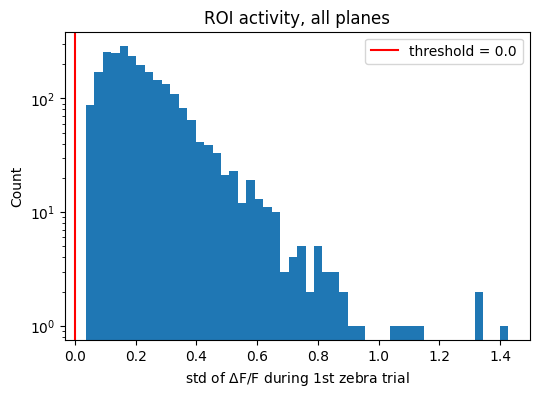

In [5]:
# Activity distribution — the ΔF/F analogue of the firing-rate screening
plt.figure(figsize=(6, 4))
activity = np.concatenate([stats[p][0].drop_duplicates('unit_id')['activity'].values for p in PLANES])
plt.hist(activity, bins=50)
plt.axvline(ACTIVITY_THRESHOLD, color='r', label=f'threshold = {ACTIVITY_THRESHOLD}')
plt.xlabel('std of $\\Delta$F/F during 1st zebra trial')
plt.ylabel('Count')
plt.yscale('log')
plt.title('ROI activity, all planes')
plt.legend()

In [6]:
# Which (plane, trial, phase) results carry RF maps?
# An .h5 written without the 'rf_maps' dataset (interrupted or older run) still has
# valid scalar statistics, but contributes nothing to any map plot.
rows = []
for plane in PLANES:
    ov_df = stats[plane][0]
    for (trial, phase), group in ov_df.groupby(['trial', 'phase']):
        rows.append({'plane': plane, 'trial': trial, 'phase': phase,
                     'n_rois': len(group), 'n_with_rf_map': len(has_rf_map(group))})
rf_map_coverage = pd.DataFrame(rows)
rf_map_coverage[rf_map_coverage['n_with_rf_map'] < rf_map_coverage['n_rois']]

,plane,trial,phase,n_rois,n_with_rf_map


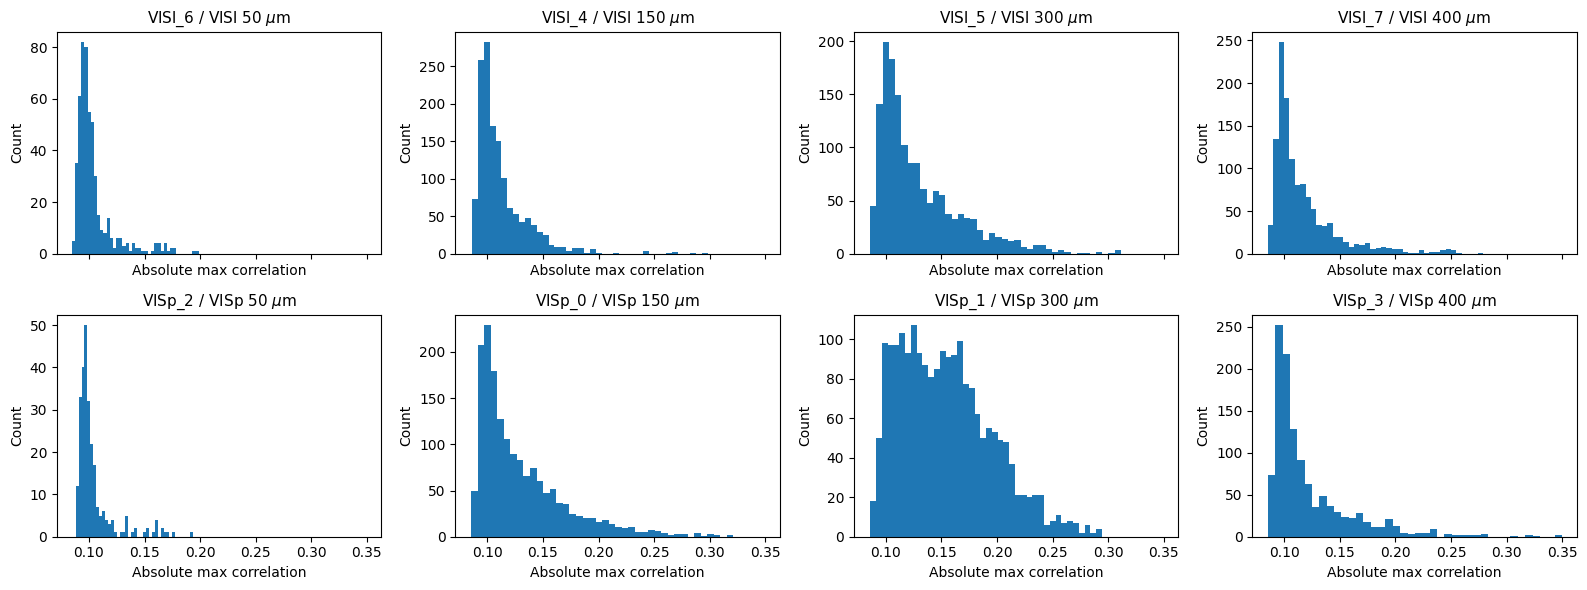

In [37]:
# Correlation distribution per plane
ncols = 4
nrows = int(np.ceil(len(PLANES) / ncols))
f, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True)
axs = np.atleast_1d(axs).flatten()
for ax, plane in zip(axs, PLANES):
    ov_df = stats[plane][0]
    ax.hist(ov_df['abs_max_value'], bins=40)
    ax.set_title(f'{plane} / {label_dict[plane]}', fontsize=11)
    ax.set_xlabel('Absolute max correlation')
    ax.set_ylabel('Count')
for ax in axs[len(PLANES):]:
    ax.set_axis_off()
f.tight_layout()

## RF size (sigma)

Only ROIs above `COR_THRESHOLD` enter the size statistics — below that the best
Gabor is essentially the argmax of noise and its sigma carries no information.
Peak correlations in this session top out around 0.32, so 0.15 keeps roughly the
upper half of the responsive ROIs; check the per-plane counts below before
reading much into a plane with only a handful left.

In [8]:
COR_THRESHOLD = 0.15

sigma_dict = {}
for plane in PLANES:
    ov_df = stats[plane][0]
    sigma_dict[plane] = ov_df.loc[ov_df['abs_max_value'] > COR_THRESHOLD, 'sigma_deg'].values

{p: len(s) for p, s in sigma_dict.items()}

{'VISl_6': 22,
 'VISl_4': 90,
 'VISl_5': 363,
 'VISl_7': 134,
 'VISp_2': 14,
 'VISp_0': 381,
 'VISp_1': 1027,
 'VISp_3': 203}

In [9]:
def bootstrap_ci(values, n_bootstrap=1000, statistic=np.median, seed=0):
    '''Percentile bootstrap CI of `statistic` over `values`.'''
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    boot = [statistic(rng.choice(values, size=len(values), replace=True)) for _ in range(n_bootstrap)]
    return np.percentile(boot, 2.5), np.percentile(boot, 97.5)

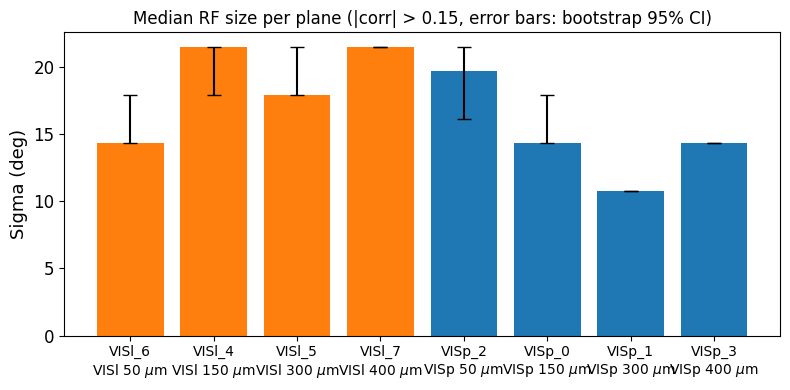

In [38]:
plt.figure(figsize=(8, 4))
for plane in PLANES:
    sigmas = sigma_dict[plane]
    if len(sigmas) == 0:
        continue
    median = np.median(sigmas)
    ci_lower, ci_upper = bootstrap_ci(sigmas)
    plt.bar(f'{plane}\n{label_dict[plane]}', median,
            yerr=[[median - ci_lower], [ci_upper - median]], capsize=5,
            color='tab:blue' if plane.startswith('VISp') else 'tab:orange')

plt.xticks(fontsize=10)
plt.yticks(fontsize=12)
plt.ylabel('Sigma (deg)', fontsize=13)
plt.title(f'Median RF size per plane (|corr| > {COR_THRESHOLD}, error bars: bootstrap 95% CI)')
plt.tight_layout()

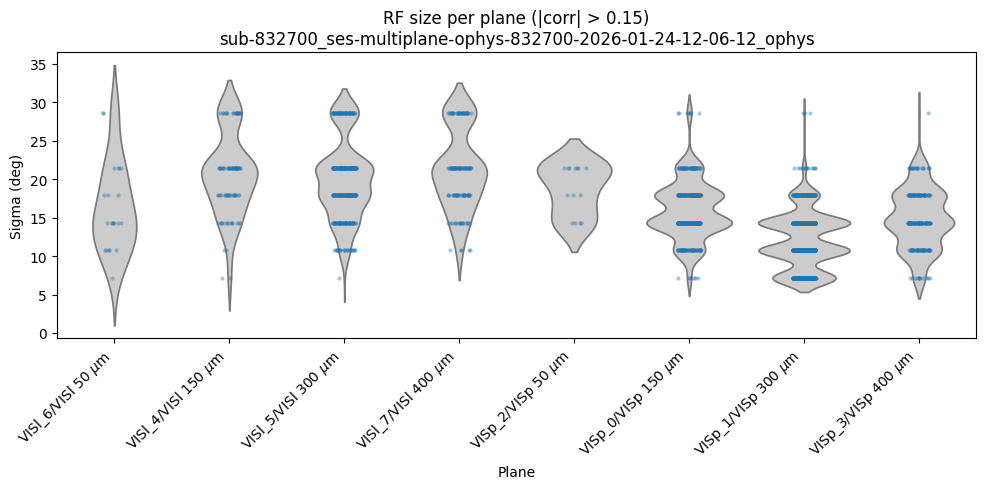

In [39]:
# Same data as a distribution rather than a point estimate
data_to_plot = [{'Plane': f'{plane}/{label_dict[plane]}', 'Sigma (deg)': sigma}
                for plane in PLANES for sigma in sigma_dict[plane]]
plot_df = pd.DataFrame(data_to_plot)

plt.figure(figsize=(10, 5))
sns.violinplot(x='Plane', y='Sigma (deg)', data=plot_df, inner=None, color='.8')
sns.stripplot(x='Plane', y='Sigma (deg)', data=plot_df, jitter=True, alpha=0.4, size=3)
plt.xticks(rotation=45, ha='right')
plt.title(f'RF size per plane (|corr| > {COR_THRESHOLD})\n{session_name}')
plt.tight_layout()
plt.show()

In [62]:
bins

array([ 0.  ,  3.58,  7.16, 10.74, 14.32, 17.9 , 21.48, 25.06, 28.64,
       32.22])

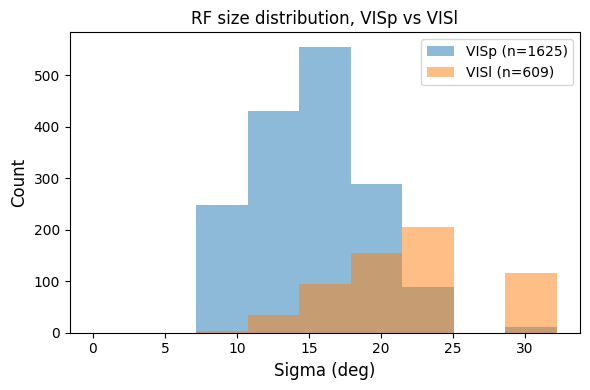

In [61]:
# Pooled by area
plt.figure(figsize=(6, 4))
for area, color in [('VISp', 'tab:blue'), ('VISl', 'tab:orange')]:
    sigmas = np.concatenate([sigma_dict[p] for p in PLANES if plane_meta(p)[0] == area])
    bins = np.arange(0, 35, 3.58)
    plt.hist(sigmas, bins=bins, alpha=0.5, label=f'{area} (n={len(sigmas)})', color=color)
plt.xlabel('Sigma (deg)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('RF size distribution, VISp vs VISl')
plt.legend()
plt.tight_layout()

## Delay and duration tuning

For each ROI: hold the best duration fixed and sweep the delay (and vice versa),
normalize each curve by its own maximum, then take the median across ROIs. The
mesoscope grid is coarser than the ecephys one — delays 0–0.15 s in 0.03 s steps,
durations {0, 0.1, 0.2} s — because the imaging rate is 9.48 Hz (~105 ms/frame).

In [ ]:
def normalized_curves(plane, sweep, cor_threshold=COR_THRESHOLD):
    '''
    Per-ROI curves of abs_max_value along `sweep` ('delay' or 'duration'),
    with the other parameter held at the ROI's optimum and each curve
    normalized by its own maximum.

    Returns (x_values, array of shape (n_curves, len(x_values))).
    '''
    ov_df, df_best, df_all, _ = stats[plane]
    fixed = 'duration' if sweep == 'delay' else 'delay'
    x_values = np.sort(df_all[sweep].unique())

    curves = []
    good = ov_df.loc[ov_df['abs_max_value'] > cor_threshold, ['unit_id', 'trial', 'phase']].drop_duplicates()
    for unit in good['unit_id'].unique():
    # for unit, trial, phase in good.itertuples(index=False):
        # best = df_best.query(f"unit_id=='{unit}' and trial=={trial} and phase=={phase}")
        best = df_best.query(f"unit_id=='{unit}'")
        if len(best) == 0:
            continue
        # sel = df_all.query(f"unit_id=='{unit}' and trial=={trial} and phase=={phase} "
        #                    f"and {fixed}=={best[fixed].values[0]}").sort_values(sweep)
        sel = df_all.query(f"unit_id=='{unit}' and {fixed}=={best[fixed].values[0]}").sort_values(sweep)
        values = sel.groupby(sweep)['abs_max_value'].median()

        if len(values) != len(x_values):
            continue
        # values = sel['abs_max_value'].values
        curves.append(values / values.max())
    return x_values, np.array(curves)

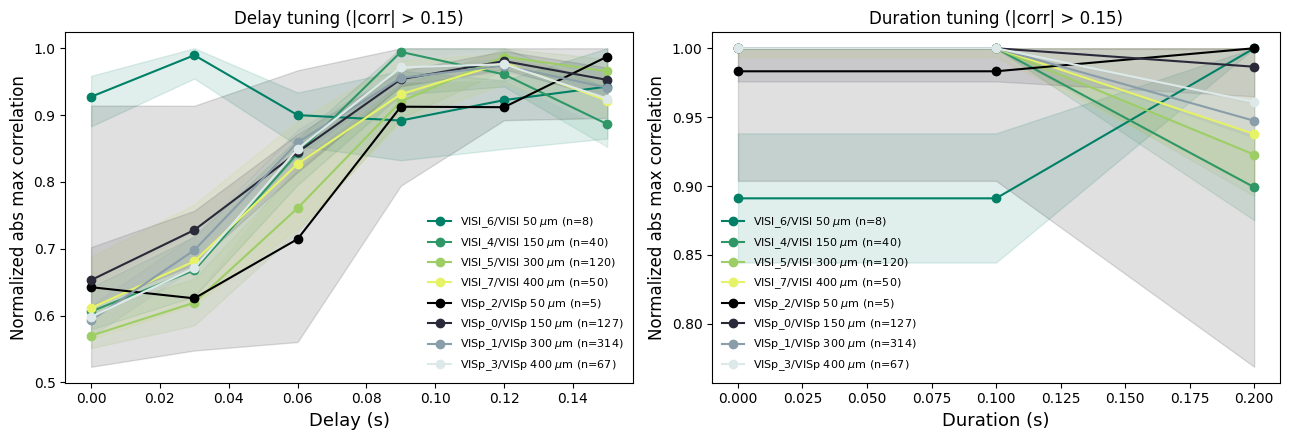

In [99]:
import matplotlib as mpl

f, axs = plt.subplots(1, 2, figsize=(13, 4.5))

for sweep, ax in zip(['delay', 'duration'], axs):
    for plane in PLANES:
        x_values, curves = normalized_curves(plane, sweep)
        if len(curves) == 0:
            continue
        median = np.median(curves, axis=0)
        ci = np.array([bootstrap_ci(curves[:, i]) for i in range(curves.shape[1])])


        # color = 'tab:blue' if plane.startswith('VISp') else 'tab:orange'
        cmap = mpl.colormaps['bone'] if plane.startswith('VISp') else mpl.colormaps['summer']
        depth = overview.loc[overview['plane']==plane, 'depth_um']
        area = overview.loc[overview['plane']==plane, 'area'].values[0]
        area_min = overview.loc[overview['area']==area, 'depth_um'].min()
        area_max = overview.loc[overview['area']==area, 'depth_um'].max()

        color = cmap((depth-area_min)/(area_max-area_min)-.1)

        # alpha = 0.35 + 0.65 * (PLANES.index(plane) % 4) / 3
        alpha = 1
        ax.plot(x_values, median, label=f'{plane}/{label_dict[plane]} (n={len(curves)})',
                color=color, alpha=alpha, marker='o')
        ax.fill_between(x_values, ci[:, 0], ci[:, 1], alpha=0.12, color=color)

    ax.set_xlabel(f'{sweep.capitalize()} (s)', fontsize=13)
    ax.set_ylabel('Normalized abs max correlation', fontsize=12)
    ax.set_title(f'{sweep.capitalize()} tuning (|corr| > {COR_THRESHOLD})')
    ax.legend(fontsize=8, frameon=False)

f.tight_layout()

## Average RF per plane

Mean of the RF maps of all ROIs surviving a correlation threshold, one row per
threshold. Color limits are matched within a column so the rows of one plane are
comparable; the number of contributing ROIs is printed in each panel. Maps of all
available trials are pooled.

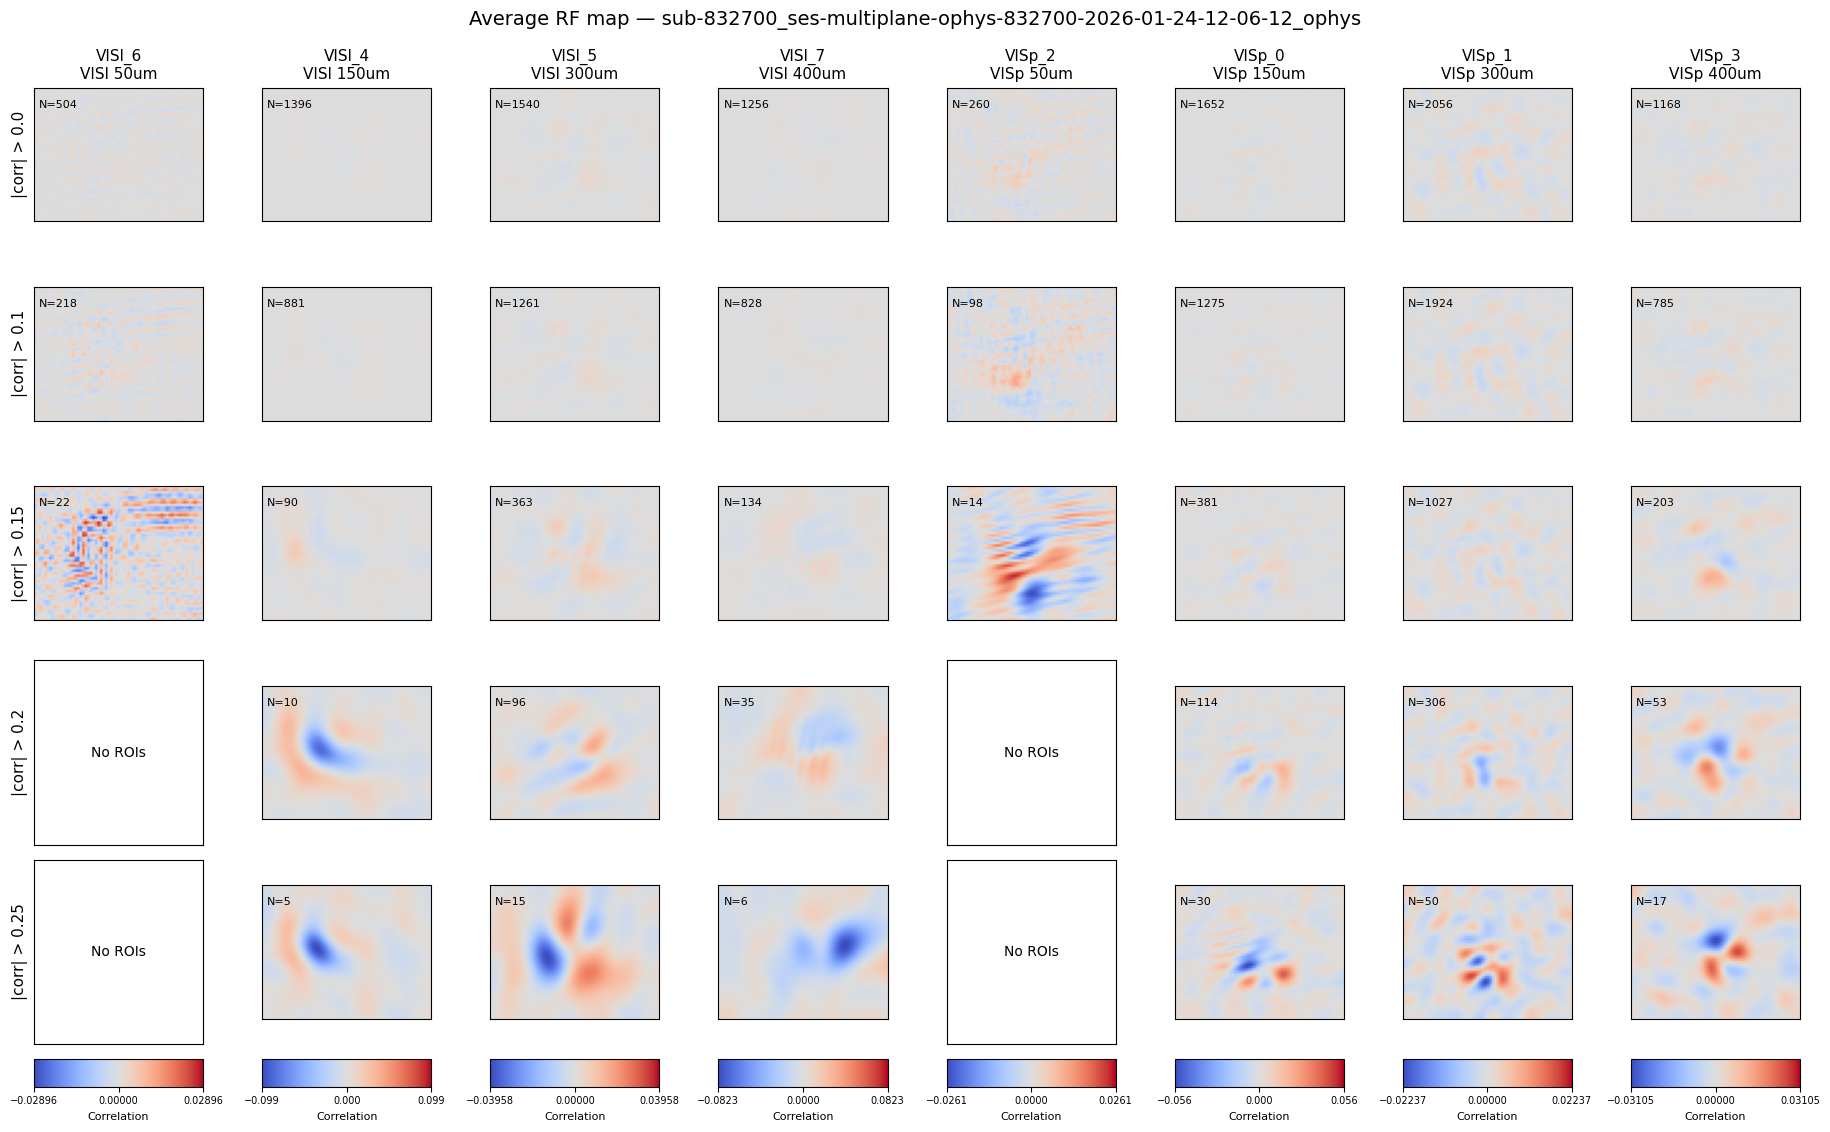

In [15]:
cor_thresholds = [0.0, 0.1, 0.15, 0.2, 0.25]

# one extra row at the bottom to hold the per-plane colorbars
f, axs = plt.subplots(len(cor_thresholds) + 1, len(PLANES),
                      figsize=(2.3 * len(PLANES), 2.1 * len(cor_thresholds) + 1),
                      height_ratios=[1] * len(cor_thresholds) + [0.15])

images = np.empty((len(cor_thresholds), len(PLANES)), dtype=object)
for i, plane in enumerate(PLANES):
    ov_df = has_rf_map(stats[plane][0])
    for j, cor_threshold in enumerate(cor_thresholds):
        ax = axs[j, i]
        ax.set_xticks([]); ax.set_yticks([])
        subset = ov_df[ov_df['abs_max_value'] > cor_threshold]
        if len(subset) == 0:
            # keep the (empty) axes so the row label on column 0 stays visible
            ax.text(0.5, 0.5, 'No ROIs', ha='center', va='center', transform=ax.transAxes)
            continue
        avg_rf = subset['rf_map'].sum() / len(subset)
        images[j, i] = ax.imshow(avg_rf.T, cmap='coolwarm')
        ax.text(0.03, 0.85, f'N={len(subset)}', transform=ax.transAxes, fontsize=8)

# match color limits within each column
for i in range(len(PLANES)):
    column = [im for im in images[:, i] if im is not None]
    if not column:
        axs[-1, i].set_axis_off()
        continue
    vmax = max(np.abs(im.get_array()).max() for im in column)
    for im in column:
        im.set_clim(-vmax, vmax)
    cbar = f.colorbar(column[-1], cax=axs[-1, i], orientation='horizontal')
    cbar.set_ticks([-vmax, 0, vmax])
    cbar.ax.tick_params(labelsize=7)
    cbar.set_label('Correlation', fontsize=8)

for j, cor_threshold in enumerate(cor_thresholds):
    axs[j, 0].set_ylabel(f'|corr| > {cor_threshold}', fontsize=11)
for i, plane in enumerate(PLANES):
    axs[0, i].set_title(f'{plane}\n{label_dict[plane]}', fontsize=11)

f.suptitle(f'Average RF map — {session_name}', fontsize=14)
f.tight_layout()
Path(PLOT_PATH).mkdir(parents=True, exist_ok=True)
f.savefig(f'{PLOT_PATH}/avg_rf_maps_per_plane.png', dpi=200, bbox_inches='tight')

## All RF maps of one plane

  0%|          | 0/517 [00:00<?, ?it/s]

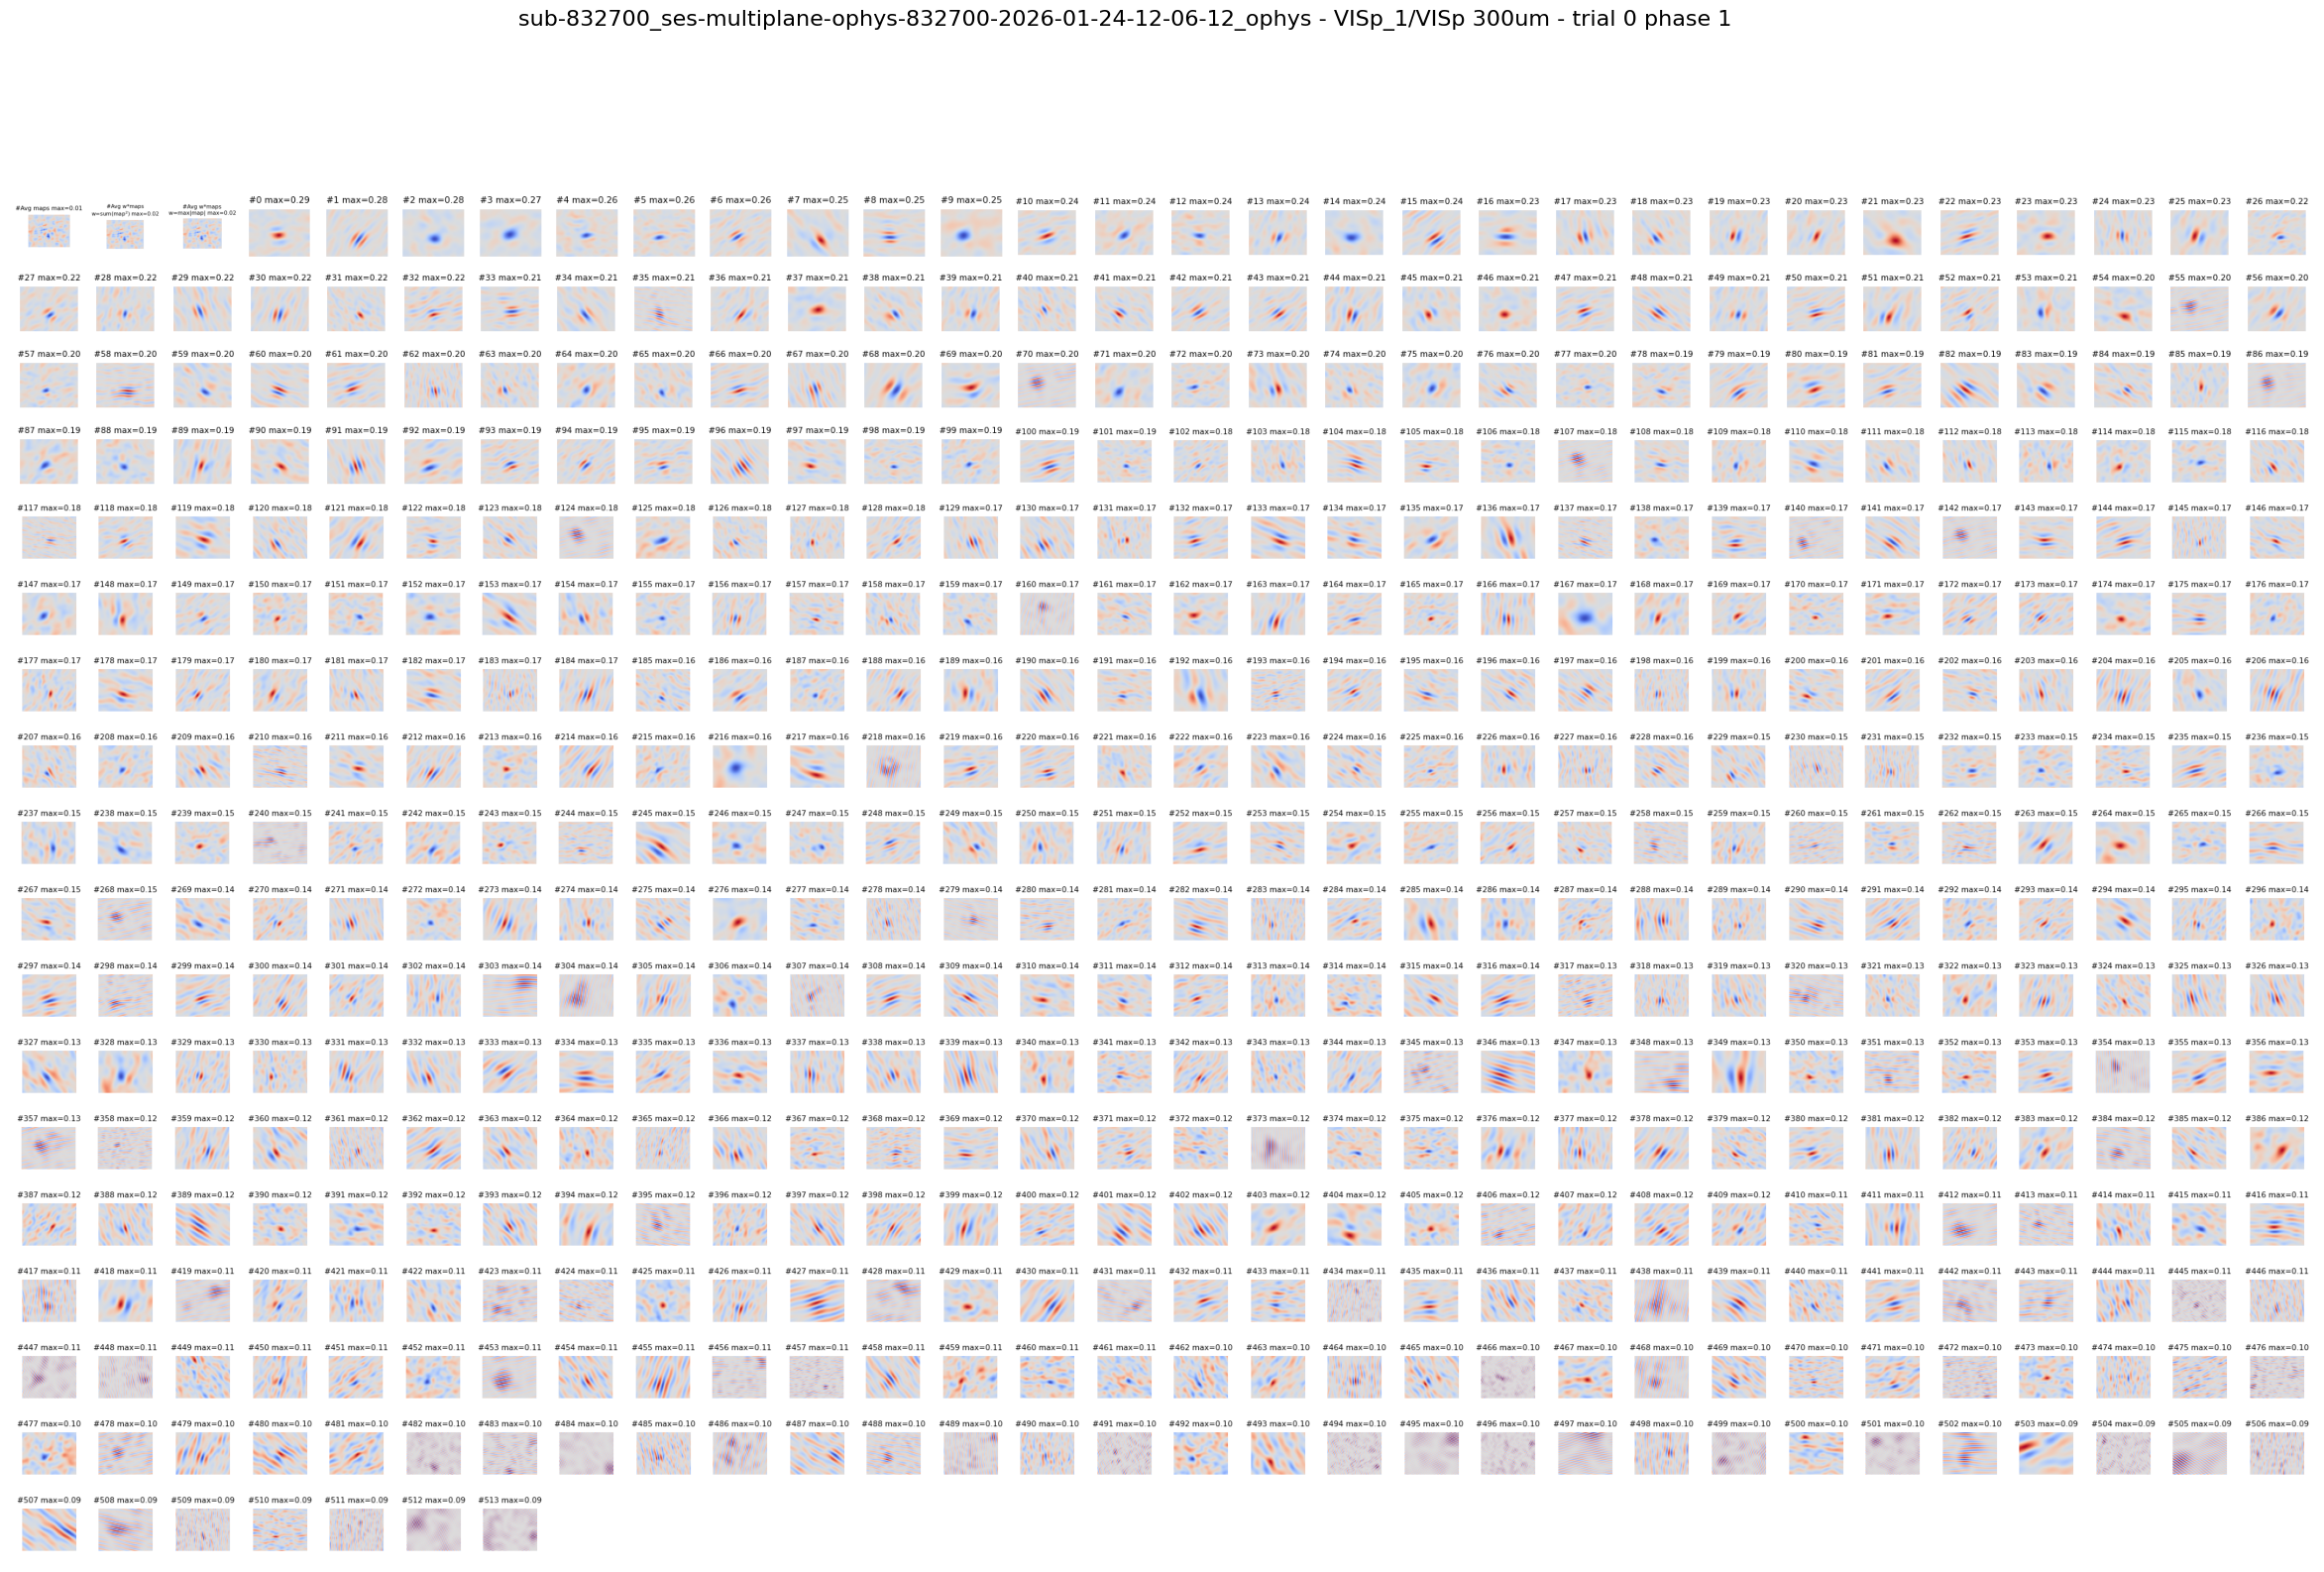

In [16]:
from parallelplot import parallel_plot

def plot_fn(data, fig, ax):
    i, map = data
    if (map != 0.).any():
        abs_max = np.abs(map).max()
        ax.imshow(map.T, cmap='coolwarm', vmin=-abs_max, vmax=abs_max)
        ax.set_aspect('equal')
        ax.set_title(f'#{i} max={abs_max:.2f}', fontsize=8)
    ax.axis('off')


plane = 'VISp_1'
trial, phase = 0, 1

ov_df = has_rf_map(stats[plane][0])
df_sorted = (ov_df.query(f'trial=={trial} and phase=={phase}')
                  .sort_values('abs_max_value', ascending=False)
                  .reset_index(drop=True))
maps = df_sorted['rf_map'].values
data = list(zip(df_sorted.index, maps))

data.insert(0, ('Avg maps', np.sum(maps) / len(maps)))

weights = df_sorted['abs_max_value'].values
data.insert(1, ('Avg w*maps\nw=max|map|', np.sum(maps * weights) / weights.sum()))

weights = np.array([np.sum(np.power(map, 2)) for map in maps])
data.insert(1, ('Avg w*maps\nw=sum(map$^2$)', np.sum(maps * weights) / weights.sum()))

f, axs = parallel_plot(data=data, plot_fn=plot_fn,
                       grid_shape=(int(len(data) / 30) + 1, 30), grid_cell_size=(1, 1))
f.suptitle(f'{session_name} - {plane}/{label_dict[plane]} - trial {trial} phase {phase}', fontsize=16)
f.savefig(f'{PLOT_PATH}/all_rfs_{plane}_trial-{trial}-phase{phase}.png', dpi=200, bbox_inches='tight')

## Best ROIs per plane

`plot_optimized_results(..., modality='mesoscope')` — RF map, best Gabor, duration
sweep and delay sweep for the `NY` best ROIs of a plane. Columns of the inner grids
are the phases present (here only π/2), rows are the trials.

Text(0.5, 1.02, 'Visp_0 / VISp 150 $\\mu$m')

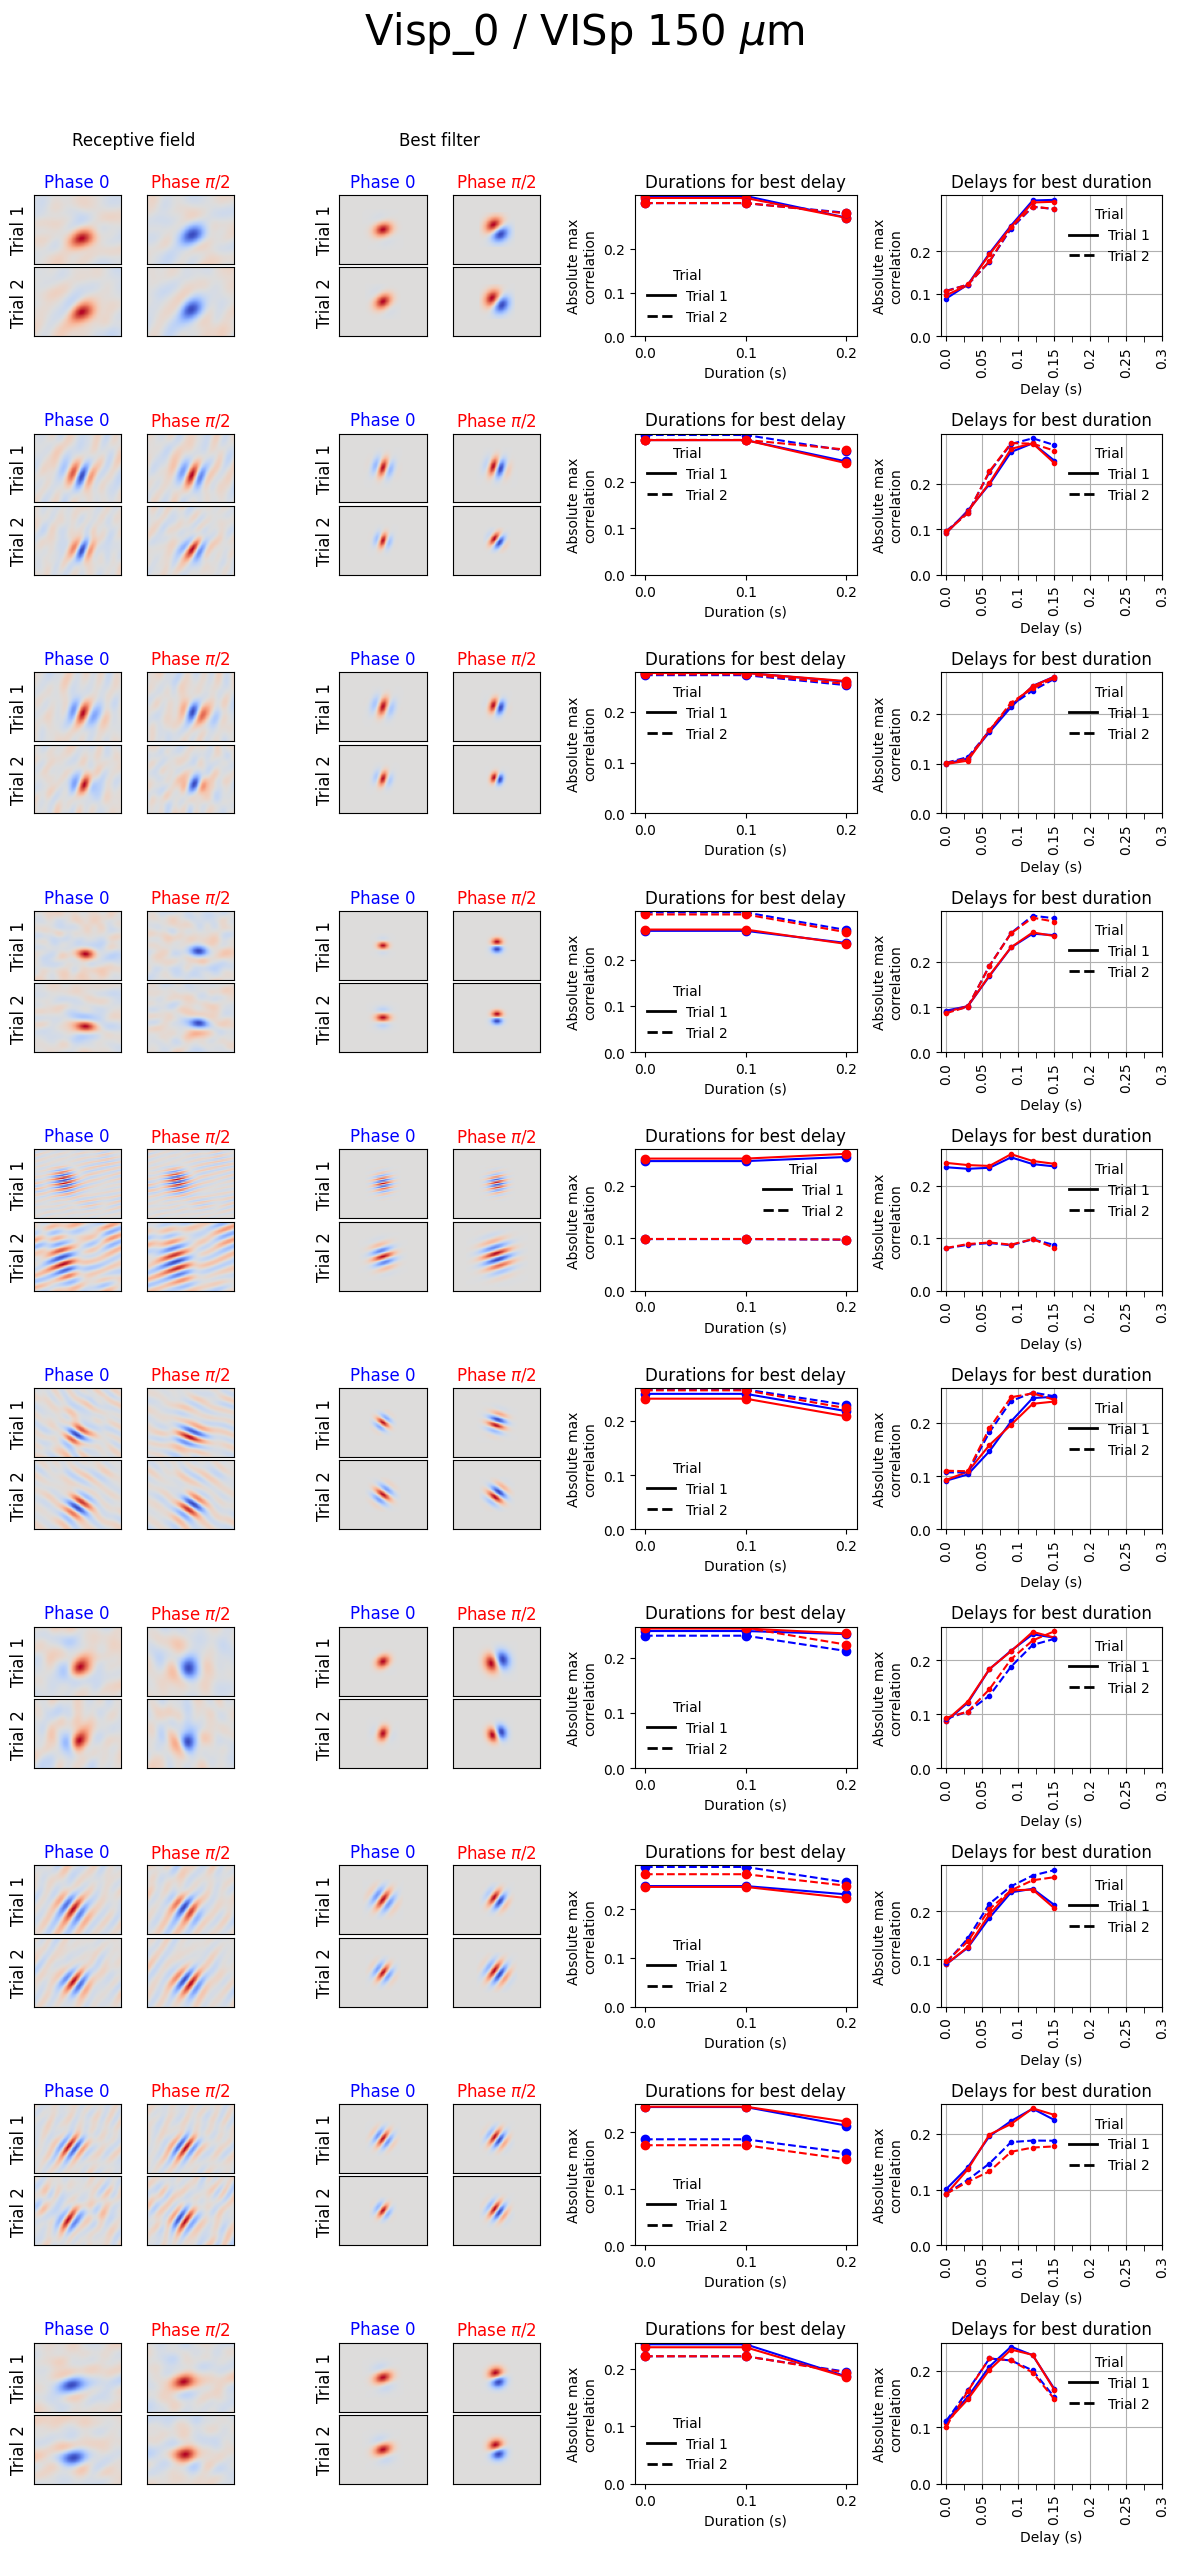

In [56]:
f, axs = plot_optimized_results('VISp_0', results_path=RESULTS_PATH, nwb_path=nwb_path, NY=10,
                       rate_threshold=ACTIVITY_THRESHOLD, path_printing=PLOT_PATH,
                       modality='mesoscope')

f.suptitle(f'Visp_0 / {label_dict['VISp_0']}', fontsize=30, y=1.02)

In [54]:
PLOT_PATH

'../plots/sub-832700_ses-multiplane-ophys-832700-2026-01-24-12-06-12_ophys'

In [57]:
for plane in PLANES:
    f, axs = plot_optimized_results(plane, results_path=RESULTS_PATH, nwb_path=nwb_path, NY=10,
                           rate_threshold=ACTIVITY_THRESHOLD, path_printing=PLOT_PATH,
                           modality='mesoscope')
    f.suptitle(f'{plane} | {label_dict[plane]}', fontsize=30, y=1.02)
    f.savefig(f'{PLOT_PATH}/{plane}_optimized_results.png', dpi=300, bbox_inches='tight')  
    plt.close('all')
print(f'saved to {PLOT_PATH}')

saved to ../plots/sub-832700_ses-multiplane-ophys-832700-2026-01-24-12-06-12_ophys
